In [2]:
from google.colab import drive
drive.mount('/content/drive')

import os
from pathlib import Path

PROJECT_DIR = Path("/content/MediScan_Medical_Image_Classification")
REPO_URL = "https://github.com/SagarSharma131006/MediScan_Medical_Image_Classification.git"

if not PROJECT_DIR.exists():
    !git clone {REPO_URL} {PROJECT_DIR}

os.chdir(PROJECT_DIR)

print("Current folder:", os.getcwd())

for folder in ["data/raw", "data/processed", "reports", "figures", "notebooks", "src", "models"]:
    Path(folder).mkdir(parents=True, exist_ok=True)

print("Folders ready.")

Mounted at /content/drive
Cloning into '/content/MediScan_Medical_Image_Classification'...
remote: Enumerating objects: 161, done.
remote: Counting objects: 100% (26/26), done.
remote: Compressing objects: 100% (13/13), done.
remote: Total 161 (delta 19), reused 13 (delta 13), pack-reused 135 (from 1)
Receiving objects: 100% (161/161), 3.13 MiB | 6.93 MiB/s, done.
Resolving deltas: 100% (61/61), done.
Current folder: /content/MediScan_Medical_Image_Classification
Folders ready.


In [3]:
import zipfile
from pathlib import Path

zip_path = Path("/content/drive/MyDrive/archive.zip")
extract_path = Path("data/raw")

if not zip_path.exists():
    raise FileNotFoundError("archive.zip Google Drive ke MyDrive folder me hona chahiye.")

if not (extract_path / "Training").exists():
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(extract_path)
    print("Dataset extracted successfully.")
else:
    print("Dataset already extracted.")

Dataset extracted successfully.


In [4]:
import os
from pathlib import Path

PROJECT_DIR = Path("/content/MediScan_Medical_Image_Classification")
os.chdir(PROJECT_DIR)

print("Current folder:", os.getcwd())

for folder in ["data/raw", "data/processed", "reports", "figures"]:
    Path(folder).mkdir(parents=True, exist_ok=True)

print("Folders ready.")

Current folder: /content/MediScan_Medical_Image_Classification
Folders ready.


In [5]:
import pandas as pd
from pathlib import Path

manifest_path = Path("data/processed/day1_dataset_manifest.csv")

if not manifest_path.exists():
    raise FileNotFoundError("Day 1 manifest nahi mila. Pehle Day 1 complete karo.")

df = pd.read_csv(manifest_path)

print("Total images:", len(df))
df.head()

Total images: 7200


,image_path,label,original_split
0,data/raw/Training/meningioma/Tr-me_1196.jpg,meningioma,Training
1,data/raw/Training/meningioma/Tr-me_520.jpg,meningioma,Training
2,data/raw/Training/meningioma/Tr-me_1193.jpg,meningioma,Training
3,data/raw/Training/meningioma/Tr-me_509.jpg,meningioma,Training
4,data/raw/Training/meningioma/Tr-me_379.jpg,meningioma,Training


In [6]:
from PIL import Image
from tqdm import tqdm

image_info = []

for image_path in tqdm(df["image_path"]):
    img = Image.open(image_path)

    image_info.append({
        "image_path": image_path,
        "width": img.width,
        "height": img.height,
        "mode": img.mode
    })

image_info_df = pd.DataFrame(image_info)
image_info_df.to_csv("data/processed/day2_image_info.csv", index=False)

image_info_df.head()

100%|██████████| 7200/7200 [00:00<00:00, 10436.36it/s]


,image_path,width,height,mode
0,data/raw/Training/meningioma/Tr-me_1196.jpg,512,512,RGB
1,data/raw/Training/meningioma/Tr-me_520.jpg,512,512,L
2,data/raw/Training/meningioma/Tr-me_1193.jpg,512,512,L
3,data/raw/Training/meningioma/Tr-me_509.jpg,512,512,RGB
4,data/raw/Training/meningioma/Tr-me_379.jpg,512,512,L


In [7]:
print("Image size summary:")
display(image_info_df[["width", "height"]].describe())

print("Image mode count:")
display(image_info_df["mode"].value_counts())

Image size summary:


,width,height
count,7200.000000,7200.000000
mean,453.302917,456.899167
std,130.048964,124.402496
min,150.000000,167.000000
25%,442.000000,449.000000
50%,512.000000,512.000000
75%,512.000000,512.000000
max,1375.000000,1446.000000


Image mode count:


,count
mode,
RGB,4129
L,3067
RGBA,3
P,1


In [8]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=42
)

train_df = train_df.copy()
val_df = val_df.copy()
test_df = test_df.copy()

train_df["split"] = "train"
val_df["split"] = "val"
test_df["split"] = "test"

split_df = pd.concat([train_df, val_df, test_df], ignore_index=True)

split_df.to_csv("data/processed/day2_train_val_test_split.csv", index=False)
train_df.to_csv("data/processed/train.csv", index=False)
val_df.to_csv("data/processed/val.csv", index=False)
test_df.to_csv("data/processed/test.csv", index=False)

print("Train images:", len(train_df))
print("Validation images:", len(val_df))
print("Test images:", len(test_df))
print("Total:", len(split_df))

Train images: 5040
Validation images: 1080
Test images: 1080
Total: 7200


In [9]:
split_summary = split_df.groupby(["split", "label"]).size().reset_index(name="count")
split_summary

,split,label,count
0,test,glioma,270
1,test,meningioma,270
2,test,notumor,270
3,test,pituitary,270
4,train,glioma,1260
5,train,meningioma,1260
6,train,notumor,1260
7,train,pituitary,1260
8,val,glioma,270
9,val,meningioma,270


In [10]:
import json

classes = sorted(df["label"].unique())
class_to_idx = {class_name: idx for idx, class_name in enumerate(classes)}

with open("data/processed/class_to_idx.json", "w") as f:
    json.dump(class_to_idx, f, indent=4)

class_to_idx

{'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}

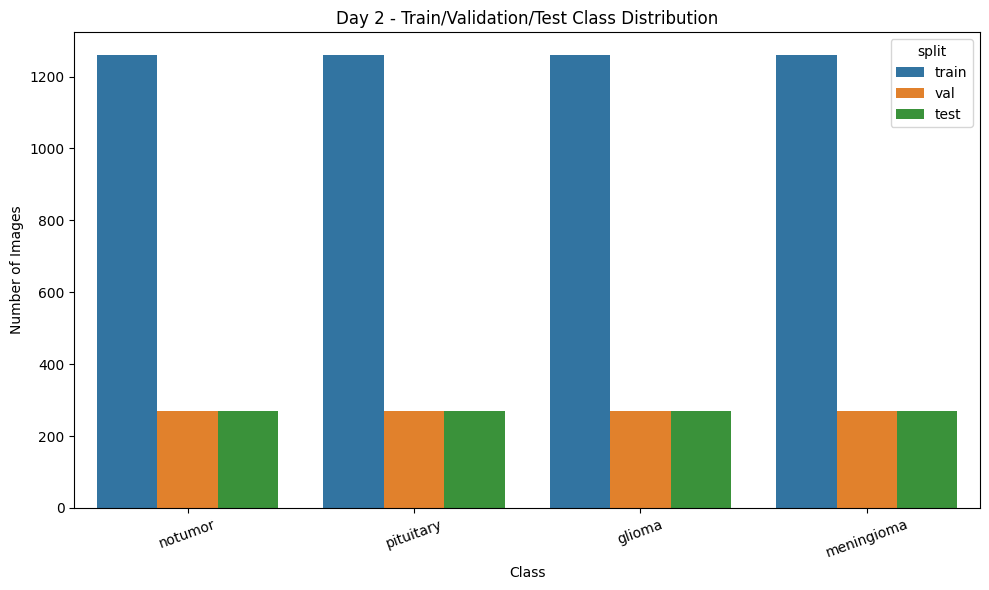

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.countplot(
    data=split_df,
    x="label",
    hue="split"
)

plt.title("Day 2 - Train/Validation/Test Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=20)
plt.tight_layout()

plt.savefig("figures/day2_split_distribution.png", dpi=150)
plt.show()

In [12]:
from pathlib import Path

summary = f"""
# Day 2 Summary - Data Preprocessing and Split

## Work Completed

- Day 1 dataset manifest loaded successfully.
- Image dimensions and image modes were inspected.
- All future model inputs will be converted to RGB format.
- Dataset was split into train, validation, and test sets.
- Stratified splitting was used to keep all classes balanced.
- Class-to-index mapping was created.
- Class distribution visualization was saved.

## Split Ratio

| Split | Images |
|---|---:|
| Train | {len(train_df)} |
| Validation | {len(val_df)} |
| Test | {len(test_df)} |
| Total | {len(split_df)} |

## Classes

{pd.Series(class_to_idx).to_markdown()}

## Key Insight

The dataset remains balanced after the 70/15/15 split. This is important because a balanced split helps the model learn all classes fairly and gives a more reliable validation and testing result.

## Output Files

- `data/processed/day2_image_info.csv`
- `data/processed/day2_train_val_test_split.csv`
- `data/processed/train.csv`
- `data/processed/val.csv`
- `data/processed/test.csv`
- `data/processed/class_to_idx.json`
- `figures/day2_split_distribution.png`
"""

Path("reports/day2_summary.md").write_text(summary)

print(summary)


# Day 2 Summary - Data Preprocessing and Split

## Work Completed

- Day 1 dataset manifest loaded successfully.
- Image dimensions and image modes were inspected.
- All future model inputs will be converted to RGB format.
- Dataset was split into train, validation, and test sets.
- Stratified splitting was used to keep all classes balanced.
- Class-to-index mapping was created.
- Class distribution visualization was saved.

## Split Ratio

| Split | Images |
|---|---:|
| Train | 5040 |
| Validation | 1080 |
| Test | 1080 |
| Total | 7200 |

## Classes

|            |   0 |
|:-----------|----:|
| glioma     |   0 |
| meningioma |   1 |
| notumor    |   2 |
| pituitary  |   3 |

## Key Insight

The dataset remains balanced after the 70/15/15 split. This is important because a balanced split helps the model learn all classes fairly and gives a more reliable validation and testing result.

## Output Files

- `data/processed/day2_image_info.csv`
- `data/processed/day2_train_val_test_split